# Preference-aligned failure margins on the egg-cooking scenario

**What this does:** A robot arm serves a toy egg from a pan to a plate. From that
task we learn a failure margin `l(x)` with DINOv2 features whose ordering represents a stated preference ordering. We compare two methods for learning the failure margin and evaluate if they encode the two opposing preference sets.

**What it shows:**
1. A VLM (Gemini Robotics-ER 1.6) is a usable, cheap labeler for egg location and short clip comparison.
2. State-level margins (per frame) over the 5 classes `{flipper, plate, flipped, fallen, both}`:
  Bradley-Terry vs regression shows close held-out accuracies. However regression gives more evenly-spaced, distinguishable values while BT compresses at the middle.
3. Clip-level margins (5-frame) with more nuanced preference sets (safety + failure mode + style) represent two preference sets (A cautious, B speed) with their failure margin values.

**Source code:** `egg/{load_data, examine_data, vlm_call, vlm_budget, vlm_diagnostics, label_states, bt_margin, regression_margin, label_pairs, clip_margin}.py`

By default the notebook loads cached labels + checkpoints. Labeling and training steps are heavy and are gated by inline toggles.

In [1]:
%matplotlib inline
import sys, json; from pathlib import Path
sys.path.insert(0, "egg")
import os; os.chdir(Path.cwd())            # run from repo root
RUN_VLM = False        # True -> re-label with the VLM (costs $, needs ~/.gemini_key)
RETRAIN = False        # True -> retrain margins from scratch (else load checkpoints)
import numpy as np, torch, matplotlib.pyplot as plt, h5py
import load_data as D

## Load & examine the data

The robot serves a toy egg from a pan to a plate. Every frame has two ground-truth failure labels, `fallen` (egg dropped onto the table) and `flipped` (egg turned over, sunny-side-down), giving four outcomes `{safe, fallen, flipped, both}`.

The failure margins are learned on DINOv2 features. `build_features()` encodes every `camera_zed_1` into DINOv2 ViT-S/14 384-d features and stores in `egg/egg_wm.h5`. `report()` prints the trajectory/frame counts and the class imbalance (safe dominates because episodes end shortly after failure).

In [2]:
import examine_data
examine_data.report()
# examine_data.taxonomy_figure()          # -> egg/out/taxonomy.png
# D.build_features()                       # rebuild egg_wm.h5 (~2 min on GPU)

EGG DATASET REPORT
trajectories: 872   frames: 182019   features: camera_zed_1 DINOv2 ViT-S/14-reg
trajectories with any failure frame: 496 (57%)

per-FRAME class (imbalanced -- episodes end soon after a failure):
   safe      170559  (93.7%)
   fallen      2458  (1.4%)
   flipped     4205  (2.3%)
   both        4797  (2.6%)

per-TRAJECTORY terminal outcome:
   safe     378
   flipped  269
   both     146
   fallen   79

taxonomy: (fallen,flipped) -> {(0,0):safe,(1,0):fallen,(0,1):flipped,(1,1):both}; blue/absent yolk = intact/flipped, plate vs table = on-plate/fallen


{'n_traj': 872,
 'n_frame': 182019,
 'frame_class': {'safe': 170559,
  'fallen': 2458,
  'flipped': 4205,
  'both': 4797},
 'terminal': {'flipped': 269, 'safe': 378, 'both': 146, 'fallen': 79}}

## VLM labeling setup

We use a VLM (**Gemini Robotics-ER 1.6**) as the labeler. Three helpers:
- `vlm_call`: REST client call
- `vlm_budget`: estimate the cost of labeling
- `vlm_diagnostics`: evaluates the VLM label quality against ground truth

The point of this section is to establish the VLM labeling is accurate enough before using it to label a large dataset.

In [3]:
import vlm_budget
vlm_budget.estimate(500, 10)     # 500 clip pairs (2x5 frames)
vlm_budget.estimate(2000, 1)     # 2000 state frames
if RUN_VLM:
    import vlm_diagnostics; vlm_diagnostics.classify(); vlm_diagnostics.preference()

[gemini-robotics-er-1.6-preview] 500 items x 10 img -> ~5.50M in / 0.03M out  =  $1.72
[gemini-robotics-er-1.6-preview] 2000 items x 1 img -> ~2.83M in / 0.12M out  =  $1.15


## v0 state-level labeling  (failure-mode + egg on flipper/plate)

The v0 experiment learns a per-frame margin over five state classes. `flipped`, `fallen`, `both`, and `safe` are ground-truth. We then split `safe` by where the egg is into `flipper` and `plate`, using the VLM (`label_egg_location`). Final classes: `{flipper, plate, flipped, fallen, both}`.

A preference set is an ordering of these five classes, defining which states the margin should score higher. We design two opposing preference sets to show that the margin values represent preference orderings and not merely detect failure.

| class | meaning | **Set A** (cautious) | **Set B** (speed) |
|---|---|:--:|:--:|
| `flipper` | egg carried on the flipper | +2 | +1 |
| `plate` | egg delivered to the plate | +1 | +2 |
| `flipped` | egg turned over | 0 | −1 |
| `fallen` | egg dropped on the table | −1 | 0 |
| `both` | flipped and fallen | −2 | −2 |

- Set A (cautious) prefers keeping the egg on the `flipper` (don't risk failure), and treats `flipped` as less bad than `fallen`.
- Set B (speed) prefers delivery to the `plate`, and treats `fallen` as less bad than `flipped`.
- Both share the common preferences (any safe > any failure, `both` worst).

In [4]:
import label_states
if RUN_VLM:
    label_states.label_egg_location(n_flipper=1000, n_plate=1000)
data_state = label_states.build_state_dataset(per_traj=40, class_cap=3000)

frames per class: {'flipper': 1000, 'plate': 806, 'flipped': 3000, 'fallen': 1513, 'both': 2797}


## State-level margins: Bradley-Terry vs regression

We learn the margin `l(x)` two ways with the same network architecture but different losses:

- Bradley-Terry (`bt_margin`) from relative preference labels and minimize `softplus(l(x_lo) − l(x_hi))`, pushing the preferred class's value above the other's. The raw value output is normalized to `[−2, 2]`.
- Regression (`regression_margin`) calculates MSE directly between the predicted values and the the preference set's targets.

We train both losses for both preference sets and report held-out accuracies.

In [5]:
import bt_margin, regression_margin
if RETRAIN:
    for s in ('A','B'): bt_margin.train(s, data=data_state); regression_margin.train(s, data=data_state)
BT  = {s: bt_margin.load(s)  for s in ('A','B')}     # (model, normalize_fn)
REG = {s: regression_margin.load(s) for s in ('A','B')}

### The two margins visualized

Each point is a held-out frame's margin value, grouped by class. Regression spaces the five classes evenly, while Bradley-Terry ranks them correctly but compresses the middle classes toward zero.

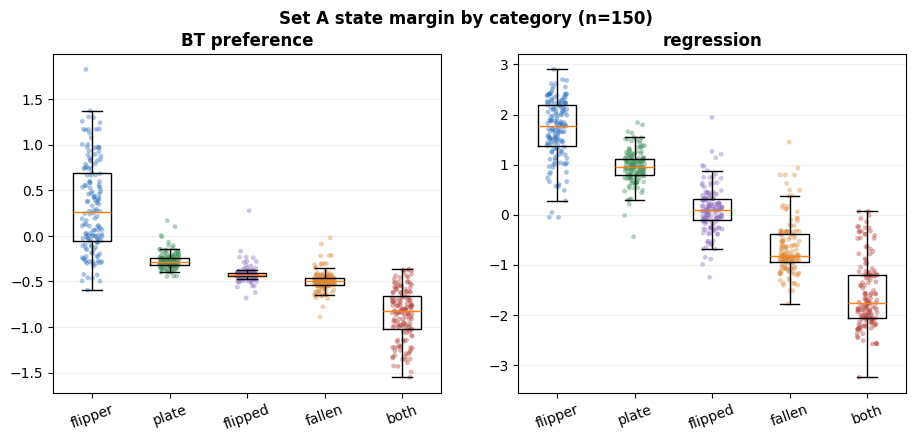

In [6]:
from label_states import CLASSES
fr = json.loads(Path('egg/labels/state_frames.json').read_text())['test']
need={}; [need.setdefault(k,set()).add(t) for c in CLASSES for k,t in fr[c]]
with h5py.File(D.H5,'r') as hf:
    a2h={hf[hk].attrs['key']:hk for hk in hf.keys()}
    cache={k:{t:np.asarray(hf[a2h[k]]['cam_embd'][t],np.float32).mean(0) for t in ts} for k,ts in need.items()}
feats={c:np.stack([cache[k][t] for k,t in fr[c]]) for c in CLASSES}
nb=min([150]+[len(feats[c]) for c in CLASSES]); rng=np.random.default_rng(0)
feats={c:feats[c][rng.choice(len(feats[c]),nb,replace=False)] for c in CLASSES}
COL={'flipper':'#2C6FBB','plate':'#3F8F5B','flipped':'#8E6FBF','fallen':'#D98A3D','both':'#B3423B'}
fig,ax=plt.subplots(1,2,figsize=(11,4.4))
for a,(tag,(m,nrm)) in zip(ax,[('BT preference',BT['A']),('regression',REG['A'])]):
    for x,c in enumerate(CLASSES):
        with torch.no_grad(): v=m(torch.tensor(feats[c],dtype=torch.float32,device='cuda:0')).cpu().numpy()
        v=nrm(v) if nrm else v
        a.scatter(np.full_like(v,x)+rng.uniform(-.13,.13,len(v)),v,s=12,alpha=.4,color=COL[c],edgecolors='none')
        a.boxplot(v,positions=[x],widths=.5,showfliers=False)
    a.set_xticks(range(5)); a.set_xticklabels(CLASSES,rotation=20); a.set_title(tag,weight='bold'); a.grid(axis='y',alpha=.2)
fig.suptitle('Set A state margin by category (n=%d)'%nb,weight='bold'); plt.show()

### Trajectory rollouts  (Set A vs Set B on the same real trajectory)

We evaluate each margin along real trajectories. The top row contains key trajectory frames, the second row has BT margins for the two preference sets, and the bottom row is the regression margins for the same two preference sets. Observe the changes in margin values when state class transitions.

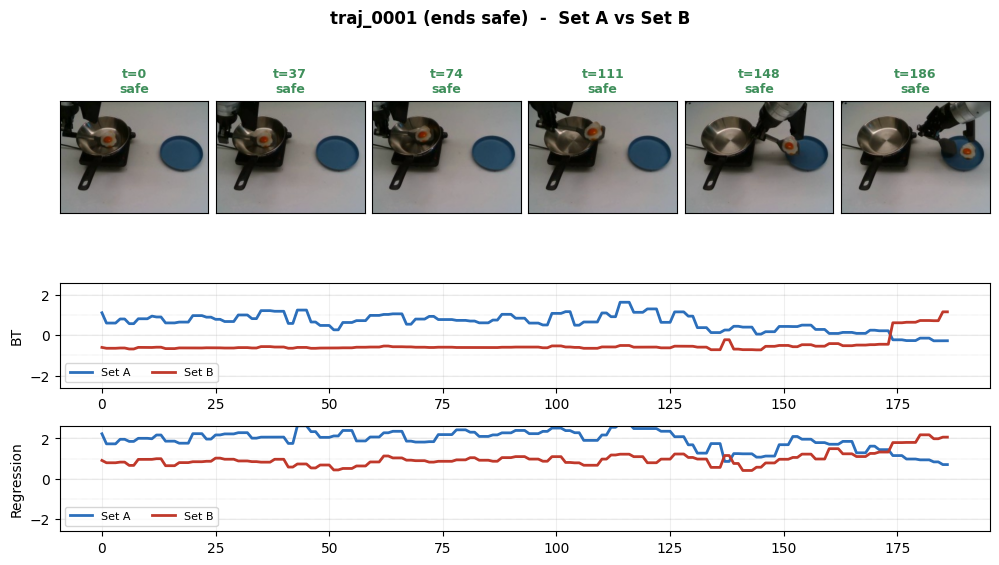

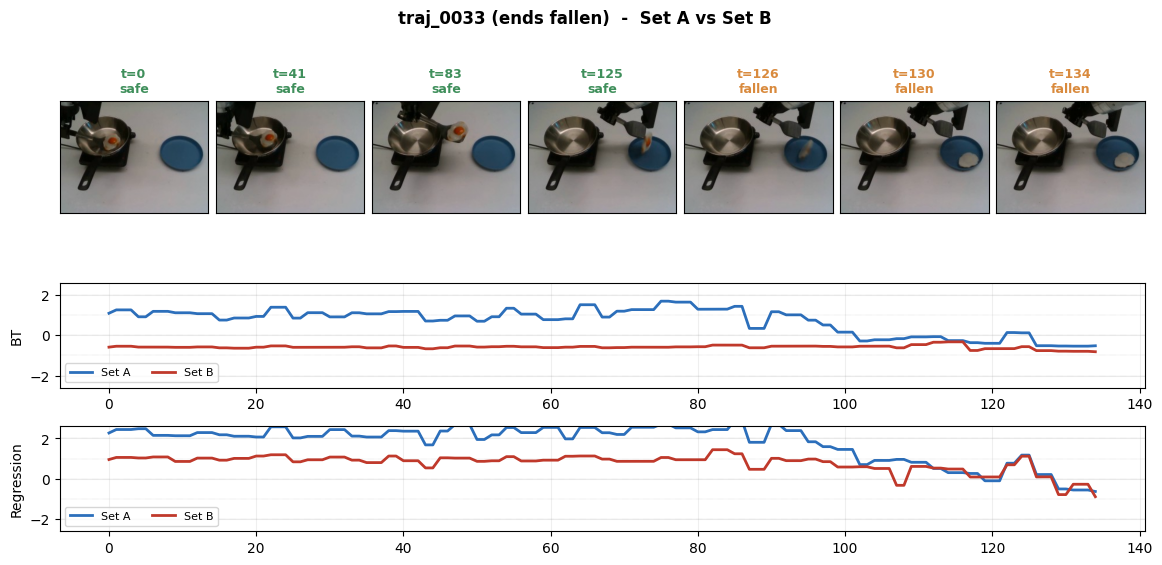

In [7]:
from matplotlib import gridspec
GTCOL={0:'#3F8F5B',1:'#D98A3D',2:'#8E6FBF',3:'#B3423B'}; GTN=['safe','fallen','flipped','both']; SC={'A':'#2C6FBB','B':'#C0392B'}
def state_rollout(key):
    with h5py.File(D.H5,'r') as hf:
        a2h={hf[hk].attrs['key']:hk for hk in hf.keys()}; g=hf[a2h[key]]
        feat=np.asarray(g['cam_embd'],np.float32).mean(1); lab=np.asarray(g['labels'])
    T=len(feat); cls=(lab[:,0]==1).astype(int)+2*(lab[:,1]==1).astype(int); x=np.arange(T)
    def curve(pair):
        m,nrm=pair
        with torch.no_grad(): v=m(torch.tensor(feat,dtype=torch.float32,device='cuda:0')).cpu().numpy()
        return nrm(v) if nrm else v
    path=D.h5_key_to_path()[key][1]
    on=int(np.argmax(cls!=0)) if (cls!=0).any() else -1
    ts=sorted(set([int(v) for v in np.linspace(0,max(on-1,1),4)]+[on,(on+T-1)//2,T-1])) if on>0 else list(np.linspace(0,T-1,6).astype(int))
    ims=D.read_frames(path,'camera_rs_0',ts)
    fig=plt.figure(figsize=(2*len(ts),6)); gs=gridspec.GridSpec(3,len(ts),height_ratios=[2,1.2,1.2],hspace=.3,wspace=.05)
    for i,(t,im) in enumerate(zip(ts,ims)):
        a=fig.add_subplot(gs[0,i]); a.imshow(im); a.set_xticks([]); a.set_yticks([]); a.set_title('t=%d\n%s'%(t,GTN[cls[t]]),color=GTCOL[cls[t]],fontsize=9,weight='bold')
    for r,(store,name) in enumerate([(BT,'BT'),(REG,'Regression')]):
        a=fig.add_subplot(gs[r+1,:])
        a.plot(x,curve(store['A']),color=SC['A'],lw=2,label='Set A'); a.plot(x,curve(store['B']),color=SC['B'],lw=2,label='Set B')
        for y in (2,1,0,-1,-2): a.axhline(y,color='k',lw=.3,ls=':',alpha=.3)
        a.set_ylim(-2.6,2.6); a.set_ylabel(name); a.legend(loc='lower left',fontsize=8,ncol=2); a.grid(alpha=.2)
    fig.suptitle('%s (ends %s)  -  Set A vs Set B'%(key.split('/')[-1],GTN[cls[-1]]),weight='bold'); plt.show()
state_rollout('260709_egg/traj_0001')   # delivery: A high on flipper, B takes over on plate
state_rollout('260709_egg/traj_0033')   # fallen

## Clip labeling for nuanced preferences

Single frames can't express behavioral preferences (how gently the egg is set down, how fast the flipper moves). So we move to 5-frame clips and richer preference sets:

1. any safe clip > any failing clip.
2. `both` is worst.
3. position (center vs edge) > motion (slow and steady vs fast) > release (lower gently vs drop from height).

`label_pairs` samples clip pairs and asks the VLM which is better (~500 pairs), then augments with ground-truth labels (`both` is worst + dispreferred safe clip still beats failure) to strengthen the ordering where VLM labeling is insufficient.

In [8]:
import label_pairs
if RUN_VLM:
    label_pairs.collect_vlm_pairs(500); label_pairs.add_both_pairs(); label_pairs.add_crosslevel_pairs()
print('clip pairs:', len(json.loads(Path('egg/labels/pref_clip_dataset.json').read_text())))

clip pairs: 830


## Clip Bradley-Terry margin

`ClipMargin` concatenates the 5 frames as input to the MLP, so it can see the temporal patterns. It's trained with the same BT loss on the clip pairs.

In [9]:
import clip_margin
if RETRAIN:
    clip_margin.train('A','concat'); clip_margin.train('A','mean'); clip_margin.train('B','concat')
CLIP={s:clip_margin.load(s,'concat') for s in ('A','B')}

### Clip margins by category (Set A)

Held-out clip margin values for preference set A grouped by ground-truth classes.

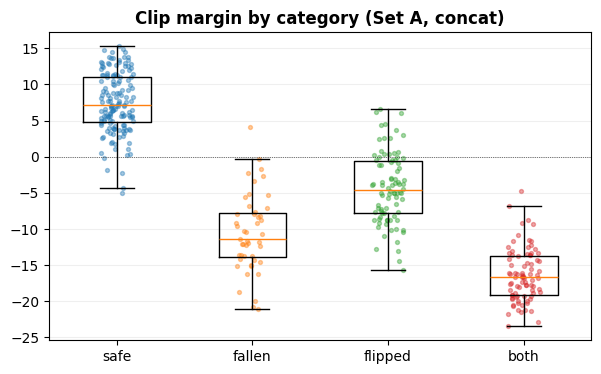

In [10]:
import label_pairs as LP, clip_margin as CM
flip,fall,safe=LP.build_pools(); both=LP.both_clips()
pools={'safe':[[w['key'],w['idx']] for w in safe][:150],'fallen':[list(w) for w in fall],
       'flipped':[list(w) for w in flip],'both':[list(w) for w in both]}
feat=CM.load_feats([{'clipA':c,'clipB':c} for cs in pools.values() for c in cs])
fig,ax=plt.subplots(figsize=(7,4))
for x,(cname,cs) in enumerate(pools.items()):
    X=torch.tensor(np.stack([feat(c) for c in cs]),dtype=torch.float32,device='cuda:0')
    with torch.no_grad(): v=CLIP['A'](X).cpu().numpy()
    ax.scatter(np.full_like(v,x)+np.random.uniform(-.12,.12,len(v)),v,s=8,alpha=.4); ax.boxplot(v,positions=[x],widths=.5,showfliers=False)
ax.set_xticks(range(len(pools))); ax.set_xticklabels(list(pools)); ax.axhline(0,color='k',lw=.5,ls=':')
ax.set_title('Clip margin by category (Set A, concat)',weight='bold'); ax.grid(axis='y',alpha=.2); plt.show()

### Clip margins along a trajectory rollout (Set A vs Set B)

The clip margin evaluated along a real trajectory for both preference sets. It shows different changes in values at the plating and failure mode critical frames.

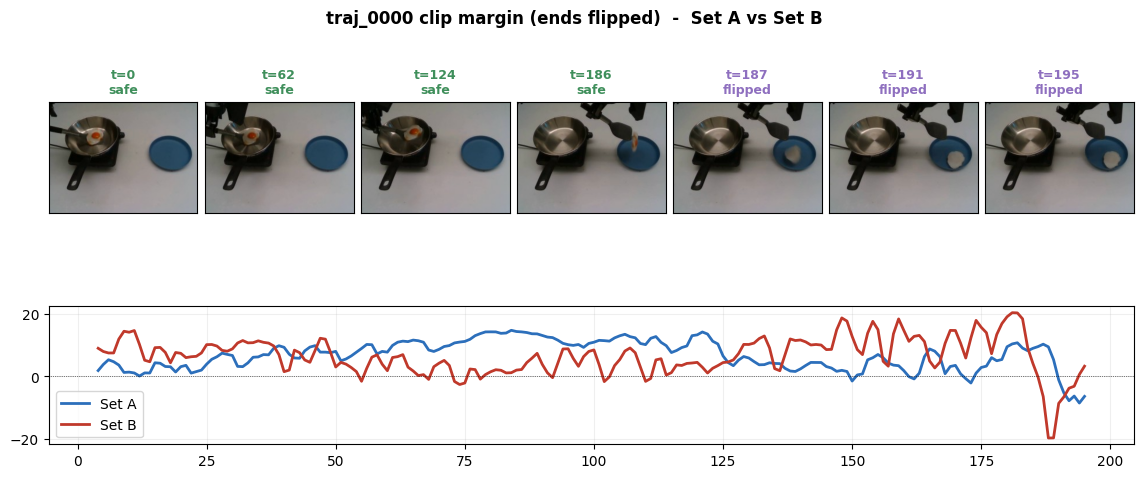

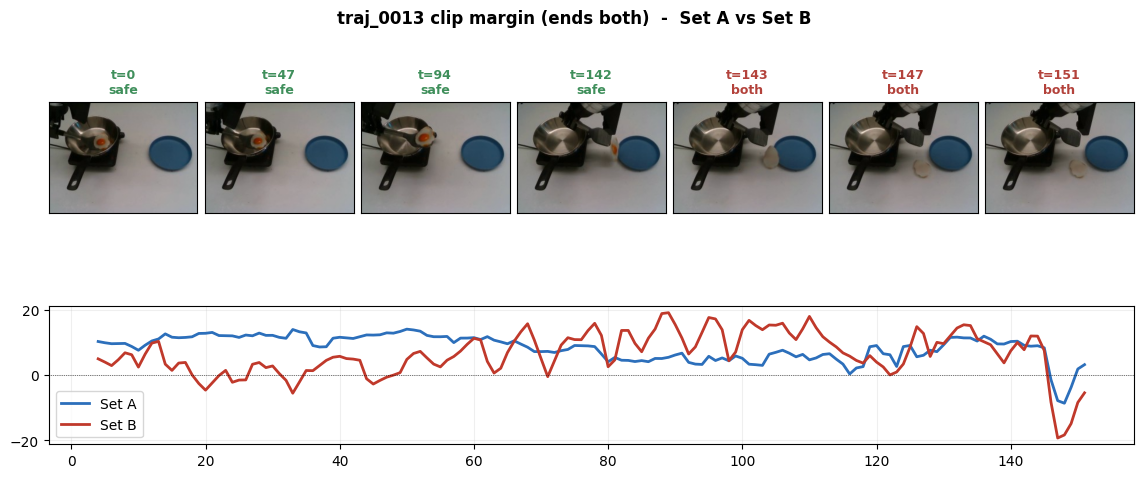

In [11]:
from matplotlib import gridspec
def clip_rollout(key,K=5):
    with h5py.File(D.H5,'r') as hf:
        a2h={hf[hk].attrs['key']:hk for hk in hf.keys()}; g=hf[a2h[key]]
        feat=np.asarray(g['cam_embd'],np.float32).mean(1); lab=np.asarray(g['labels'])
    T=len(feat); cls=(lab[:,0]==1).astype(int)+2*(lab[:,1]==1).astype(int)
    wins=np.stack([feat[t-K+1:t+1] for t in range(K-1,T)])
    # trajectory key frames (top row) -- same selection style as the state rollout
    path=D.h5_key_to_path()[key][1]
    on=int(np.argmax(cls!=0)) if (cls!=0).any() else -1
    ts=sorted(set([int(v) for v in np.linspace(0,max(on-1,1),4)]+[on,(on+T-1)//2,T-1])) if on>0 else list(np.linspace(0,T-1,6).astype(int))
    ims=D.read_frames(path,'camera_rs_0',ts)
    fig=plt.figure(figsize=(2*len(ts),5)); gs=gridspec.GridSpec(2,len(ts),height_ratios=[2,1.4],hspace=.3,wspace=.05)
    for i,(t,im) in enumerate(zip(ts,ims)):
        a=fig.add_subplot(gs[0,i]); a.imshow(im); a.set_xticks([]); a.set_yticks([]); a.set_title('t=%d\n%s'%(t,GTN[cls[t]]),color=GTCOL[cls[t]],fontsize=9,weight='bold')
    a=fig.add_subplot(gs[1,:])
    for s,col in (('A','#2C6FBB'),('B','#C0392B')):
        with torch.no_grad(): v=CLIP[s](torch.tensor(wins,dtype=torch.float32,device='cuda:0')).cpu().numpy()
        full=np.full(T,np.nan); full[K-1:]=v; a.plot(full,color=col,lw=2,label='Set '+s)
    a.axhline(0,color='k',lw=.5,ls=':'); a.legend(loc='lower left'); a.grid(alpha=.2)
    fig.suptitle('%s clip margin (ends %s)  -  Set A vs Set B'%(key.split('/')[-1],GTN[cls[-1]]),weight='bold'); plt.show()
clip_rollout('260709_egg/traj_0000')   # flipped
clip_rollout('260709_egg/traj_0013')   # both